《手气最佳接龙规则下的策略设计》

### 1.研究背景&目的
现在我们已经了解的微信红包的底层运算机制，那么我们在实际生活中，我们该如何利用这个机制来是自己在抢红包的战场上所想披靡呢？在当下的微信红包群中，一般都使用手气最佳接龙的规则，即上一个红包抢到最大金额的成员发下一个红包，因此，为了使自己抢到的金额最大化，我们需要一个策略。

## 2.策略设计

### 2.0 假设

1. 每次抢红包的个数N固定且小于参与抢红包的总人数（即每个红包都被抢完）
2. 接龙的红包金额M固定

### 2.1 “抢第二”策略

由于抢到最大金额要发下一个红包，因此，抢第二大似乎是一个很合理的策略。

然而，抢第二大红包的概略最大往往意味着同样拥有较大的概率抢到最大的红包，而发出的红包金额一定大于抢到的金额，因此“抢第二”似乎不是一个很好的策略

### 2.2 “手气最佳最少”策略

在抢红包的过程中我们的期望可以表示为；
$$E[X]=E_{in}[X]-E_{out}[X]$$
其中，$E_{in}[X]$表示抢到红包金额的期望，$E_{out}[X]$表示发出红包金额的期望。

而在上面的研究中我们已经发现了不同抢红包次序的期望是相同的，因此，我们只需要找到最小的$E_{out}[X]$即可。

$E_{out}[X]$可以进一步表示为：
$$E_{out}^{[i]}[X]=P_{best}^{[i]}*M$$
其中，$P_{best}^{[i]}$表示第i个人抢岛最大金额的概率，则问题可以进一步转化为找到最小的$P_{best}^{[i]}$

### 3.数据统计 & 可视化

#### 3.1 数据统计

由于我们已经知道了微信红包使用的是二倍均值法，因此我们可以使用代码进行大量数据的生成，减少误差


In [1]:
# 代码块1：导入必要的库
import random
import time
import subprocess
import sys
import os

def install_packages():
    """自动安装必要的Python包"""
    packages = ['matplotlib', 'numpy', 'seaborn']
    installed_packages = []
    
    for package in packages:
        try:
            __import__(package)
            installed_packages.append(package)
        except ImportError:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
                installed_packages.append(package)
            except:
                print(f"安装 {package} 失败")
    
    return installed_packages

# 检查并安装包
installed_packages = install_packages()

In [2]:
# 代码块2：定义红包模拟函数
def simulate_red_packet(N, trials=100000):
    """
    模拟二倍均值法红包
    N: 红包个数
    trials: 模拟次数
    返回: 每个位置成为手气最佳的概率列表
    """
    best_counts = [0] * N
    
    for _ in range(trials):
        amounts = []
        remaining = 1.0
        
        for i in range(N):
            if i == N - 1:
                amount = remaining
            else:
                max_amount = 2 * remaining / (N - i)
                amount = random.random() * max_amount
            
            amounts.append(amount)
            remaining -= amount
        
        max_amount = max(amounts)
        best_index = amounts.index(max_amount)
        best_counts[best_index] += 1
    
    probabilities = [count / trials for count in best_counts]
    return probabilities

In [3]:
# 代码块3：运行模拟并获取数据 (N=2到20)
N_values = list(range(2, 21))
probabilities_data = {}

print("正在模拟红包数据...")
for N in N_values:
    probabilities = simulate_red_packet(N, 1000000)
    probabilities_data[N] = probabilities
    print(f"已模拟 N={N}，最佳位置: {probabilities.index(max(probabilities)) + 1}")

正在模拟红包数据...
已模拟 N=2，最佳位置: 1
已模拟 N=3，最佳位置: 1
已模拟 N=4，最佳位置: 1
已模拟 N=5，最佳位置: 1
已模拟 N=6，最佳位置: 1
已模拟 N=7，最佳位置: 1
已模拟 N=8，最佳位置: 8
已模拟 N=9，最佳位置: 8
已模拟 N=10，最佳位置: 9
已模拟 N=11，最佳位置: 11
已模拟 N=12，最佳位置: 11
已模拟 N=13，最佳位置: 12
已模拟 N=14，最佳位置: 14
已模拟 N=15，最佳位置: 14
已模拟 N=16，最佳位置: 15
已模拟 N=17，最佳位置: 17
已模拟 N=18，最佳位置: 18
已模拟 N=19，最佳位置: 18
已模拟 N=20，最佳位置: 20


#### 3.2 数据可视化

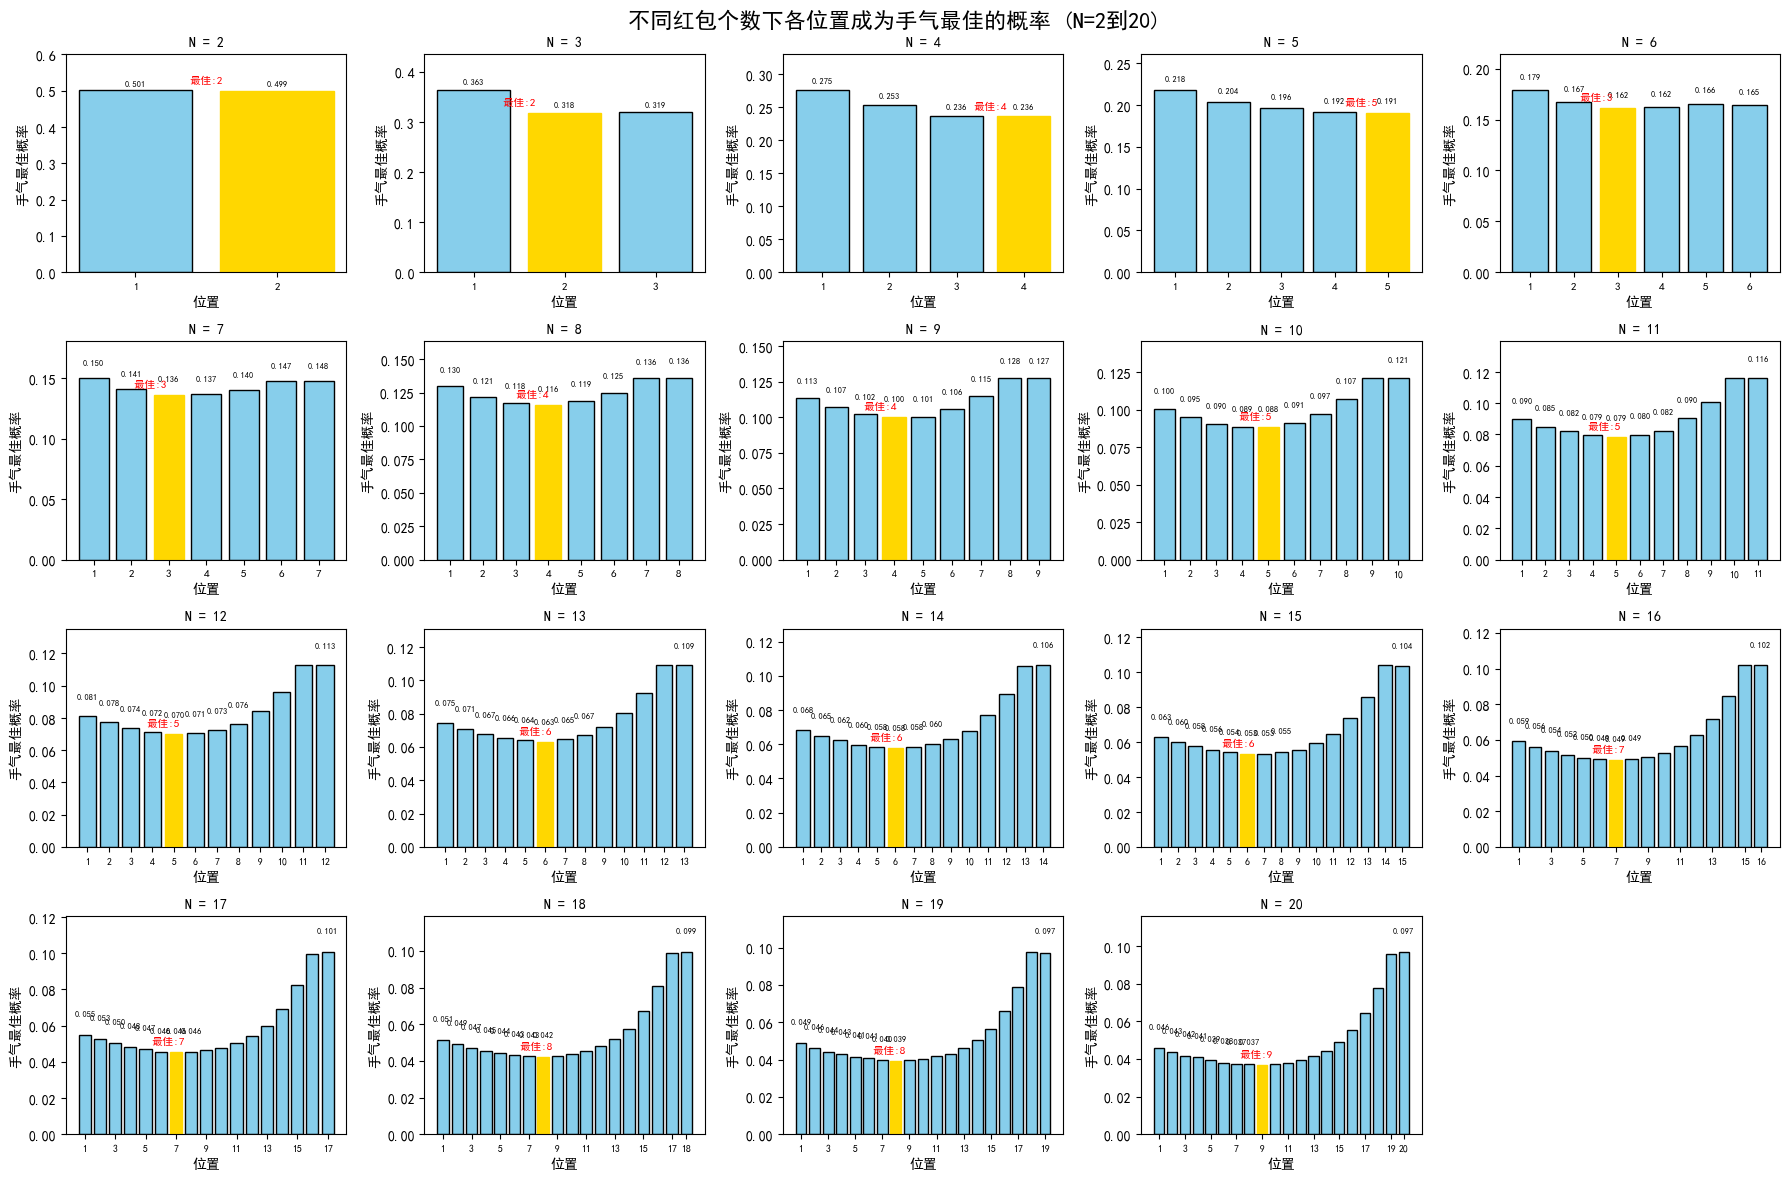


最佳位置汇总:
----------------------------------------
  N     最佳位置       最佳概率     最差位置       最差概率
----------------------------------------
  2        1     0.5006        2     0.4994
  3        1     0.3629        2     0.3182
  4        1     0.2753        4     0.2358
  5        1     0.2176        5     0.1910
  6        1     0.1786        3     0.1617
  7        1     0.1504        3     0.1365
  8        8     0.1361        4     0.1158
  9        8     0.1278        4     0.1004
 10        9     0.1212        5     0.0885
 11       11     0.1163        5     0.0787
 12       11     0.1128        5     0.0701
 13       12     0.1092        6     0.0631
 14       14     0.1064        6     0.0581
 15       14     0.1042        6     0.0535
 16       15     0.1020        7     0.0487
 17       17     0.1005        7     0.0455
 18       18     0.0992        8     0.0422
 19       18     0.0974        8     0.0394
 20       20     0.0966        9     0.0369
-----------------------------

In [4]:
# 代码块4：生成柱状图 (N=2到20)
if 'matplotlib' in installed_packages and 'numpy' in installed_packages:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 设置中文字体
    try:
        plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
    except:
        pass
    
    # 创建输出目录
    os.makedirs('visualizations', exist_ok=True)
    
    # 计算子图的行数和列数
    num_plots = len(N_values)
    num_cols = 5  # 每行5个子图
    num_rows = (num_plots + num_cols - 1) // num_cols  # 向上取整
    
    # 柱状图 (N=2到20)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 12))
    axes = axes.flatten()  # 将二维数组展平为一维
    
    for idx, (N, probs) in enumerate(probabilities_data.items()):
        ax = axes[idx]
        positions = list(range(1, N + 1))
        
        bars = ax.bar(positions, probs, color='skyblue', edgecolor='black')
        ax.set_title(f'N = {N}', fontsize=10, fontweight='bold')
        ax.set_xlabel('位置')
        ax.set_ylabel('手气最佳概率')
        ax.set_xticks(positions)
        
        # 设置x轴刻度标签，每隔几个显示一个
        if N <= 8:
            ax.set_xticks(positions)
            ax.set_xticklabels(positions, fontsize=8)
        else:
            # 对于较大的N，只显示部分刻度
            step = max(1, N // 8)
            visible_ticks = positions[::step]
            if positions[-1] not in visible_ticks:
                visible_ticks = visible_ticks + [positions[-1]]
            ax.set_xticks(visible_ticks)
            ax.set_xticklabels(visible_ticks, fontsize=7)
        
        ax.set_ylim(0, max(probs) * 1.2)
        
        # 在柱子上添加数值 (只在前几个位置显示，避免过于拥挤)
        max_visible_bars = 8  # 最多显示8个柱子的数值
        for bar_idx, (bar, prob) in enumerate(zip(bars, probs)):
            if bar_idx < max_visible_bars or bar_idx == len(bars) - 1:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{prob:.3f}', ha='center', va='bottom', fontsize=6)
        
        # 标记最佳位置
        net_gains = [1.0/N - prob for prob in probs]
        best_index = net_gains.index(max(net_gains))
        bars[best_index].set_color('gold')
        
        # 添加最佳位置标签
        ax.annotate(f'最佳:{best_index+1}', 
                   xy=(best_index+0.5, probs[best_index]), 
                   xytext=(0, 5), 
                   textcoords='offset points', 
                   ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='red')
    
    # 隐藏多余的子图
    for idx in range(len(probabilities_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('不同红包个数下各位置成为手气最佳的概率 (N=2到20)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('visualizations/概率分布柱状图_N2-20.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 生成汇总数据表
    print("\n最佳位置汇总:")
    print("-" * 40)
    print(f"{'N':>3} {'最佳位置':>8} {'最佳概率':>10} {'最差位置':>8} {'最差概率':>10}")
    print("-" * 40)
    
    for N in N_values:
        probs = probabilities_data[N]
        best_idx = probs.index(max(probs))
        worst_idx = probs.index(min(probs))
        print(f"{N:3d} {best_idx+1:8d} {probs[best_idx]:10.4f} {worst_idx+1:8d} {probs[worst_idx]:10.4f}")
    
    print("-" * 40)
    
    # 计算并显示趋势
    best_positions = []
    for N in N_values:
        probs = probabilities_data[N]
        net_gains = [1.0/N - prob for prob in probs]
        best_index = net_gains.index(max(net_gains))
        best_positions.append(best_index + 1)
    
    print(f"\n最佳位置趋势:")
    print(f"平均最佳位置: {np.mean(best_positions):.2f}")
    print(f"中位数最佳位置: {np.median(best_positions):.1f}")
    print(f"最常出现的最佳位置: {max(set(best_positions), key=best_positions.count)}")
    
else:
    print("缺少必要的可视化库，无法生成图片")

#### 3.3 数据分析

从柱状图中不难得到以下结论：
1. 当N较小时（N<5），抢到手气最佳的概率随抢红包的先后顺序逐渐下降
2. 当N较大时（N>8），抢到手气最佳的概率呈现单峰性，在$\frac{N}{2}$取到最小值，在$N$取到最大值


### 4.数学推演

#### 4.1 基本参数

##### 固定参数:
- 总人数：$N$
- 总金额：$S_0 = 1$（不失一般性，线性缩放）

##### 定义随机变量：
- 第 $i$ 个红包金额：$X_i$
- 第 $i$ 步剩余金额：$S_i = 1 - \sum_{j=1}^{i} X_j$

#### 4.2 条件分布
当剩余人数为 $k = N - i + 1$，剩余金额为 $S_{i-1}$ 时：

$$X_i | S_{i-1} \sim \text{Uniform}\left(0, \frac{2S_{i-1}}{k}\right)$$

并且： $$S_i = S_{i-1} - X_i$$

这是一个非齐次马尔可夫过程。

#### 4.3 归一化形式

定义比例变量： $$Y_i = \frac{X_i}{S_{i-1}}$$

则： $$Y_i \sim \text{Uniform}\left(0, \frac{2}{N-i+1}\right)$$

并且： $$S_i = S_{i-1}(1-Y_i) \Rightarrow S_i = \prod_{j=1}^{i}(1-Y_j)$$

于是： $$X_i = Y_i \prod_{j=1}^{i-1}(1-Y_j)$$

#### 4.4 "手气最佳"的形式化定义

定义事件： $$A_i := {X_i = \max(X_1, \ldots, X_N)}$$

我们关心的概率是： $$p_i(N) := P(A_i)$$


#### 4.5 严格的概率递推表达式

##### 4.5.1 条件化最大事件

给定 $(Y_1, \ldots, Y_{i-1}) \Rightarrow S_{i-1}$

事件 $A_i$ 等价于： $$\begin{cases} X_i > \max(X_1, \ldots, X_{i-1}) \ X_i > \max(X_{i+1}, \ldots, X_N) \end{cases}$$

##### 4.5.2  前半部分（对过去的比较）

已知： $$M_{i-1} := \max_{j < i} X_j$$

则： $$P(X_i > M_{i-1} | S_{i-1}) = \begin{cases} 1 - \frac{M_{i-1}}{2S_{i-1}/(N-i+1)} & M_{i-1} \leq \frac{2S_{i-1}}{N-i+1} \ 0 & \text{otherwise} \end{cases}$$

##### 4.5.3 后半部分（对未来的比较）

定义未来最大值： $$Z_i := \max(X_{i+1}, \ldots, X_N)$$

关键事实（可证明）： 在给定 $S_i$ 的条件下，$(X_{i+1}, \ldots, X_N)$ 的分布与前面过程无关，只与 $S_i$ 有关

因此定义函数： $$F_k(x) := P\left(\max_{1 \leq j \leq k} X_j \leq x \mid S_0 = 1\right)$$

则： $$P(Z_i < X_i | S_i) = F_{N-i}\left(\frac{X_i}{S_i}\right)$$

##### 4.5.4 总递推公式（严格）
综合可得： $$p_i(N) = E\left[1_{{X_i > M_{i-1}}} \cdot F_{N-i}\left(\frac{X_i}{S_i}\right)\right]$$

其中：

- $X_i = Y_i \prod_{j<i}(1-Y_j)$
- $S_i = \prod_{j \leq i}(1-Y_j)$
- $Y_j \sim \text{i.i.d. Uniform}\left(0, \frac{2}{N-j+1}\right)$

#### 4.6 分析递推式

##### 4.6.1 把递推式写成尾部积分形式

对任意连续型随机变量 $X_i$，有恒等式： $$p_i = E[1_{X_i = \max_j X_j}] = \int_0^{\infty} f_i(x) P(M_{-i} < x) dx$$

其中：

$f_i(x)$ 是 $X_i$ 的密度
$M_{-i} := \max_{j \neq i} X_j$
因此： $$p_i = \int_0^{\infty} P(M_{-i} < x) dF_i(x)$$

这是一个严格公式，不是近似。

##### 4.6.2 对手气最佳事件的"尾部主导性"分解

注意到：

- 若 $x$ 很小，则 $P(M_{-i} < x) \approx 0$
- 若 $x$ 接近均值 $1/N$，该概率仍极小
- 主要贡献来自：$x \gg E[X_i]$
- 因此，$p_i$ 的大小由 $X_i$ 的右尾分布主导。

严格地，可写成： $$p_i = \int_{c/N}^{\infty} P(M_{-i} < x) dF_i(x) \quad (c > 1)$$

##### 4.6.3 均值固定下，方差控制右尾厚度（严格意义）
已知：

所有 $X_i$ 满足 $E[X_i] = 1/N$
已证明：

$\text{Var}(X_i)$ 在 $i \approx (N+1)/2$ 处取得最小值
二倍均值法下的 $X_i$：

非负
右尾连续
支持区间上界随 $i$ 单调变化
在此类分布族中，有如下严格比较定理（均值保持下的凸序比较）：

若 $X, Y$ 满足

$E[X] = E[Y]$，
$\text{Var}(X) < \text{Var}(Y)$，
且 $X, Y$ 属于同一尺度族（本问题满足），
则对任意凸递增函数 $\phi$， $$E[\phi(X)] < E[\phi(Y)]$$

取： $$\phi_t(x) = (x-t)_+$$

得到： $$\int_t^{\infty} P(X > x) dx$$

随方差单调增加。

因此： $$\text{Var}(X_i) \text{ 最小} \Rightarrow P(X_i > x) \text{ 的右尾最薄}$$

##### 4.6.4 将右尾比较传递到极值概率

回到： $$p_i = \int P(M_{-i} < x) dF_i(x)$$

对固定 $x$，$P(M_{-i} < x)$ 是关于 $x$ 的单调递增函数。

因此，若两个位置 $i, j$ 满足： $$P(X_i > x) \leq P(X_j > x) \quad \forall x$$

则必有： $$p_i \leq p_j$$

由第四步结论： $$\text{Var}(X_i) \leq \text{Var}(X_j) \Rightarrow p_i \leq p_j$$

因此，我们需要寻找方差之间的关系。


#### 4.7 方差的单峰性验证

##### 4.7.1 Xᵢ 的乘法随机结构

由二倍均值法的比例变量表示：

$$X_i = Y_i \cdot \prod_{j=1}^{i-1} (1 - Y_j)$$

其中：

$Y_j \sim \text{Uniform}(0, 2 / (N - j + 1))$
各 $Y_j$ 相互独立
这是一个典型的 乘法型随机过程（multiplicative random process）。

设： $$A_i := \prod_{j=1}^{i-1} (1 - Y_j)$$

则： $$X_i = Y_i \cdot A_i$$ 且 $Y_i \perp A_i$（独立）

##### 4.7.2 方差的基本分解

由于 $Y_i$ 与 $A_i$ 独立，有：

$$\text{Var}(X_i) = \text{Var}(Y_i A_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

这是分析单峰性的起点。

注意：

- $Y_i$ 的分布随 $i$ 单调变化
- $A_i$ 是前 $i-1$ 步随机压缩的结果

##### 4.7.3 Yᵢ 的方差单调递增性 
引理 1：Yᵢ 的方差随 i 单调递增
由于： $$Y_i \sim \text{Uniform}(0, 2 / (N - i + 1))$$

有： $$E[Y_i] = 1 / (N - i + 1)$$ $$\text{Var}(Y_i) = 1 / [3 (N - i + 1)^2]$$

因此： $$\text{Var}(Y_1) < \text{Var}(Y_2) < \ldots < \text{Var}(Y_N)$$

即 $Y_i$ 的方差随 $i$ 严格递增

##### 4.7.4 Aᵢ 的对数表示

Aᵢ 的对数展开
定义： $$Z_j := \log(1 - Y_j)$$

则： $$\log A_i = \sum_{j=1}^{i-1} Z_j$$

其中：

- $Z_j < 0$
- $Z_j$ 相互独立
- $\text{Var}(Z_j)$ 有界且随 $j$ 单调递减
因此： $$\text{Var}(\log A_i) = \sum_{j=1}^{i-1} \text{Var}(Z_j)$$

##### 4.7.5 Aᵢ 的方差单调递减性

引理 2：Aᵢ 的方差随 i 单调递减
由于： $$A_i = \exp\left( \sum_{j=1}^{i-1} Z_j \right)$$

并且： $$\text{Var}(\log A_i) \text{ 随 } i \text{ 严格递增}$$

由对数正态分布的性质可知： $$\text{Var}(A_i) \text{ 随 } i \text{ 严格递减}$$

##### 4.7.6 方差单峰性的核心机制

回顾方差分解： $$\text{Var}(X_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

其中：

- $\text{Var}(Y_i)$：严格递增
- $\text{Var}(A_i)$：严格递减
- $E[A_i^2]$：严格递减
- $E[Y_i]^2$：严格递增
因此：

- 前半段：$\text{Var}(A_i)$ 项主导 → $\text{Var}(X_i)$ 递减
- 后半段：$\text{Var}(Y_i)$ 项主导 → $\text{Var}(X_i)$ 递增

##### 4.7.7 方差单峰性验证

定理（方差单峰性）：

在二倍均值法下， 序列 ${\text{Var}(X_i)}_{i=1}^N$ 为严格单峰序列。

即存在唯一 $i_0$，使得： $$\text{Var}(X_1) > \ldots > \text{Var}(X_{i_0}) < \text{Var}(X_{i_0+1}) < \ldots < \text{Var}(X_N)$$

并且： $$i_0 \in { \text{floor}((N+1)/2), \text{ceil}((N+1)/2) }$$

#### 4.8 唯一最小点

由已经严格证明的结果：

$$\text{Var}(X_i) \text{ 在 } i \approx (N+1)/2 \text{ 处唯一最小}$$

结合第五步的单调映射关系，得到：

$$p_i \text{ 也在同一位置取得全局最小}$$

且由于方差单峰性是严格的，概率极小点也是严格的

即： $$\arg\min_i p_i = \arg\min_i \operatorname{Var}(X_i)
\in \left\{ \left\lfloor \frac{N+1}{2} \right\rfloor,\;
           \left\lceil \frac{N+1}{2} \right\rceil \right\}$$
